# pi0.5-DROID vs Base PaliGemma Weight Map

Compare the shared PaliGemma weights in a converted `pi05_droid` checkpoint against the original pretrained PaliGemma backbone (`google/paligemma-3b-pt-224`). This notebook is weight-only: it does not load DROID examples, run inference, or compare activations.

The main output is a visual map of where weights differ across the vision tower, multimodal projector, and language model. Use it to quickly spot which layers/components moved most during fine-tuning, then drill into individual tensors with the selector.

## Setup Notes

If `pi05_droid` is available only as a JAX checkpoint, convert it once to a PyTorch `model.safetensors` checkpoint:

```bash
uv run examples/convert_jax_model_to_pytorch.py \
  --checkpoint_dir /home/$USER/.cache/openpi/openpi-assets/checkpoints/pi05_droid \
  --output_path /home/$USER/.cache/openpi/openpi-assets/checkpoints/pi05_droid_pytorch
```

The baseline PaliGemma download may require Hugging Face access approval and a local HF token. Set `PI05_DROID_TORCH_DIR` if your converted checkpoint is not under `models/pi05_droid_pytorch`.

In [1]:
# Optional, depending on your environment.
# !pip install matplotlib pandas safetensors transformers ipywidgets

In [2]:
from __future__ import annotations

import gc
import math
import os
from pathlib import Path
import re
import sys
import types
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import safetensors.torch
import torch
import torch.nn.functional as F
from IPython.display import display
from transformers import PaliGemmaForConditionalGeneration

In [3]:
REPO_ROOT = Path(os.environ.get("OPENPI_REPO_ROOT", "/fs/nexus-scratch/mrislam/openpi"))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from openpi.models import pi0_config
from openpi.models_pytorch import pi0_pytorch
from openpi.shared import download

PI05_DROID_GS = "gs://openpi-assets/checkpoints/pi05_droid"
PI05_DROID_JAX_DIR = Path(os.environ.get("PI05_DROID_JAX_DIR", REPO_ROOT / "models/pi05_droid")).expanduser()
PI05_DROID_TORCH_DIR = Path(os.environ.get("PI05_DROID_TORCH_DIR", REPO_ROOT / "models/pi05_droid_pytorch")).expanduser()
BASE_PALIGEMMA_ID = os.environ.get("BASE_PALIGEMMA_ID", "google/paligemma-3b-pt-224")

# CPU is enough because this notebook compares tensors, not activations. Use CUDA only if you want faster loading.
DEVICE = torch.device(os.environ.get("WEIGHT_COMPARE_DEVICE", "cpu"))
DTYPE = torch.float32
OUTPUT_DIR = Path("outputs/weight_compare/pi05_droid_vs_paligemma")
SAVE_METRICS = False

print(f"repo={REPO_ROOT}")
print(f"device={DEVICE}, dtype={DTYPE}")

repo=/fs/nexus-scratch/mrislam/openpi
device=cpu, dtype=torch.float32


## Model Loading

In [4]:
def ensure_pi05_torch_checkpoint(torch_dir: Path) -> Path:
    safetensors_path = torch_dir / "model.safetensors"
    if safetensors_path.exists():
        return safetensors_path

    local_jax_dir = PI05_DROID_JAX_DIR if PI05_DROID_JAX_DIR.exists() else download.maybe_download(PI05_DROID_GS)
    raise FileNotFoundError(
        "Could not find a converted pi05_droid PyTorch checkpoint at "
        f"{safetensors_path}. Convert the JAX checkpoint with:\n"
        f"uv run examples/convert_jax_model_to_pytorch.py --checkpoint_dir {local_jax_dir} --output_path {torch_dir}"
    )


def load_pi05_vlm(torch_dir: Path):
    config = types.SimpleNamespace(model=pi0_config.Pi0Config(pi05=True, action_dim=32, action_horizon=16, pytorch_compile_mode=None))
    model = pi0_pytorch.PI0Pytorch(config.model)
    safetensors.torch.load_model(model, str(ensure_pi05_torch_checkpoint(torch_dir)), strict=False)
    model.eval().to(DEVICE)
    return model.paligemma_with_expert.paligemma


def load_base_paligemma():
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        BASE_PALIGEMMA_ID,
        torch_dtype=DTYPE,
        low_cpu_mem_usage=True,
    )
    model.eval().to(DEVICE)
    return model


pi05_vlm = load_pi05_vlm(PI05_DROID_TORCH_DIR)
base_vlm = load_base_paligemma()
print("pi05 VLM:", type(pi05_vlm).__name__)
print("base VLM:", type(base_vlm).__name__)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

pi05 VLM: PaliGemmaForConditionalGeneration
base VLM: PaliGemmaForConditionalGeneration


## Weight Metrics

Metric guide:

- `rel_rms_delta`: RMS difference divided by average RMS weight magnitude. This is usually the most useful heatmap value.
- `cosine_distance`: `1 - cosine_similarity` after flattening both tensors. This catches directional changes even when scale is similar.
- `mean_abs_delta` and `max_abs_delta`: absolute difference magnitudes in raw weight units.
- `changed_fraction`: fraction of elements whose absolute difference is greater than the tolerance below. This is useful for detecting untouched or nearly untouched tensors.

In [5]:
DIFF_ATOL = 1e-7


def parse_weight_name(name: str) -> dict[str, str | int | None]:
    if name.startswith("model.vision_tower.vision_model.encoder.layers."):
        match = re.match(r"model\.vision_tower\.vision_model\.encoder\.layers\.(\d+)\.(.*)", name)
        tail = match.group(2) if match else name
        layer = int(match.group(1)) if match else None
        return {"group": "vision", "layer": layer, "component": tail.rsplit(".", 1)[0], "param": tail.rsplit(".", 1)[-1]}
    if name.startswith("model.language_model.layers."):
        match = re.match(r"model\.language_model\.layers\.(\d+)\.(.*)", name)
        tail = match.group(2) if match else name
        layer = int(match.group(1)) if match else None
        return {"group": "language", "layer": layer, "component": tail.rsplit(".", 1)[0], "param": tail.rsplit(".", 1)[-1]}
    if name.startswith("model.multi_modal_projector"):
        tail = name.removeprefix("model.multi_modal_projector.")
        return {"group": "projector", "layer": None, "component": tail.rsplit(".", 1)[0], "param": tail.rsplit(".", 1)[-1]}
    if name.startswith("model.vision_tower"):
        tail = name.removeprefix("model.vision_tower.")
        return {"group": "vision_other", "layer": None, "component": tail.rsplit(".", 1)[0], "param": tail.rsplit(".", 1)[-1]}
    if name.startswith("model.language_model") or name.startswith("language_model"):
        tail = name.removeprefix("model.language_model.").removeprefix("language_model.")
        return {"group": "language_other", "layer": None, "component": tail.rsplit(".", 1)[0], "param": tail.rsplit(".", 1)[-1]}
    return {"group": "other", "layer": None, "component": name.rsplit(".", 1)[0], "param": name.rsplit(".", 1)[-1]}


def canonical_component(component: str) -> str:
    replacements = {
        "self_attn.q_proj": "attn.q",
        "self_attn.k_proj": "attn.k",
        "self_attn.v_proj": "attn.v",
        "self_attn.o_proj": "attn.o",
        "self_attn.out_proj": "attn.o",
        "mlp.gate_proj": "mlp.gate",
        "mlp.up_proj": "mlp.up",
        "mlp.down_proj": "mlp.down",
        "mlp.fc1": "mlp.fc1",
        "mlp.fc2": "mlp.fc2",
        "input_layernorm": "norm.input",
        "post_attention_layernorm": "norm.post_attn",
        "layer_norm1": "norm.1",
        "layer_norm2": "norm.2",
    }
    return replacements.get(component, component)


def compare_weights(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12) -> dict[str, float | tuple[int, ...]]:
    if a.shape != b.shape:
        min_shape = tuple(min(x, y) for x, y in zip(a.shape, b.shape, strict=False))
        warnings.warn(f"Shape mismatch {tuple(a.shape)} vs {tuple(b.shape)}; cropping to {min_shape}")
        slices = tuple(slice(0, s) for s in min_shape)
        a = a[slices]
        b = b[slices]

    a = a.detach().float().cpu()
    b = b.detach().float().cpu()
    diff = a - b
    af = a.reshape(-1)
    bf = b.reshape(-1)
    df = diff.reshape(-1)
    rms_a = torch.sqrt(torch.mean(af.square())).item()
    rms_b = torch.sqrt(torch.mean(bf.square())).item()
    rms_delta = torch.sqrt(torch.mean(df.square())).item()
    cosine = F.cosine_similarity(af[None], bf[None], dim=-1).item() if af.numel() > 0 else float("nan")
    return {
        "shape": tuple(a.shape),
        "numel": int(a.numel()),
        "mean_a": a.mean().item(),
        "mean_b": b.mean().item(),
        "std_a": a.std().item() if a.numel() > 1 else 0.0,
        "std_b": b.std().item() if b.numel() > 1 else 0.0,
        "mean_delta": diff.mean().item(),
        "mean_abs_delta": diff.abs().mean().item(),
        "max_abs_delta": diff.abs().max().item(),
        "rms_delta": rms_delta,
        "rel_rms_delta": rms_delta / (0.5 * (rms_a + rms_b) + eps),
        "cosine": cosine,
        "cosine_distance": 1.0 - cosine,
        "changed_fraction": (diff.abs() > DIFF_ATOL).float().mean().item(),
    }


def build_weight_metrics(pi05_vlm, base_vlm) -> pd.DataFrame:
    pi_state = pi05_vlm.state_dict()
    base_state = base_vlm.state_dict()
    shared_names = sorted(set(pi_state) & set(base_state))
    rows = []
    for name in shared_names:
        if not torch.is_floating_point(pi_state[name]) or not torch.is_floating_point(base_state[name]):
            continue
        parsed = parse_weight_name(name)
        metrics = compare_weights(pi_state[name], base_state[name])
        rows.append({
            "name": name,
            **parsed,
            "component_short": canonical_component(str(parsed["component"])),
            **metrics,
        })
    return pd.DataFrame(rows)


metrics_df = build_weight_metrics(pi05_vlm, base_vlm)
print(f"shared floating tensors: {len(metrics_df):,}")
print(f"shared parameters compared: {metrics_df['numel'].sum():,}")
display(metrics_df.head())

/tmp/ipykernel_385418/201303830.py:50: UserWarning: Shape mismatch (257152, 2048) vs (257216, 2048); cropping to (257152, 2048)
  warnings.warn(f"Shape mismatch {tuple(a.shape)} vs {tuple(b.shape)}; cropping to {min_shape}")


shared floating tensors: 604
shared parameters compared: 3,449,982,704


,name,group,layer,component,param,component_short,shape,numel,mean_a,mean_b,std_a,std_b,mean_delta,mean_abs_delta,max_abs_delta,rms_delta,rel_rms_delta,cosine,cosine_distance,changed_fraction
0,lm_head.weight,other,NaN,lm_head,weight,lm_head,"(257152, 2048)",526647296,-0.000090,1.747477e-03,0.192841,0.183998,-0.001837,0.053185,1.615411,0.075484,0.400609,1.088960,-0.088960,0.999999
1,model.language_model.embed_tokens.weight,language_other,NaN,embed_tokens,weight,embed_tokens,"(257152, 2048)",526647296,-0.000090,1.747477e-03,0.192841,0.183998,-0.001837,0.053185,1.615411,0.075484,0.400609,1.088960,-0.088960,0.999999
2,model.language_model.layers.0.input_layernorm....,language,0.0,input_layernorm,weight,norm.input,"(2048,)",2048,0.854672,1.106530e+00,1.106307,1.159378,-0.251858,0.251889,0.539062,0.275681,0.183772,0.992388,0.007612,0.909180
3,model.language_model.layers.0.mlp.down_proj.we...,language,0.0,mlp.down_proj,weight,mlp.down,"(2048, 16384)",33554432,0.000005,-8.319485e-07,0.036241,0.022540,0.000006,0.022018,2.746686,0.027872,0.948360,0.642107,0.357893,0.999997
4,model.language_model.layers.0.mlp.gate_proj.we...,language,0.0,mlp.gate_proj,weight,mlp.gate,"(16384, 2048)",33554432,0.000092,6.628640e-05,0.038606,0.021546,0.000025,0.023929,0.255472,0.030024,0.998268,0.635690,0.364310,0.999998


In [6]:
summary_cols = [
    "name", "group", "layer", "component_short", "param", "shape", "numel",
    "rel_rms_delta", "cosine_distance", "mean_abs_delta", "max_abs_delta", "changed_fraction",
]

display(metrics_df[summary_cols].sort_values("rel_rms_delta", ascending=False).head(30))

group_summary = (
    metrics_df.groupby("group", dropna=False)
    .apply(lambda g: pd.Series({
        "tensors": len(g),
        "params": int(g["numel"].sum()),
        "weighted_rel_rms_delta": np.average(g["rel_rms_delta"], weights=g["numel"]),
        "weighted_cosine_distance": np.average(g["cosine_distance"], weights=g["numel"]),
        "max_rel_rms_delta": g["rel_rms_delta"].max(),
    }))
    .sort_values("weighted_rel_rms_delta", ascending=False)
)
display(group_summary)

,name,group,layer,component_short,param,shape,numel,rel_rms_delta,cosine_distance,mean_abs_delta,max_abs_delta,changed_fraction
166,model.multi_modal_projector.linear.weight,projector,NaN,linear,weight,"(2048, 1152)",2359296,1.402396,0.423955,0.020051,1.582987,0.999996
88,model.language_model.layers.17.self_attn.k_pro...,language,17.0,attn.k,weight,"(256, 2048)",524288,1.180227,0.535450,0.018451,0.117561,1.000000
165,model.multi_modal_projector.linear.bias,projector,NaN,linear,bias,"(2048,)",2048,1.155353,0.303792,0.013802,1.448645,1.000000
85,model.language_model.layers.17.mlp.gate_proj.w...,language,17.0,mlp.gate,weight,"(16384, 2048)",33554432,1.152214,0.483134,0.027626,0.571208,0.999997
86,model.language_model.layers.17.mlp.up_proj.weight,language,17.0,mlp.up,weight,"(16384, 2048)",33554432,1.151051,0.481736,0.030901,1.312637,0.999998
76,model.language_model.layers.16.mlp.gate_proj.w...,language,16.0,mlp.gate,weight,"(16384, 2048)",33554432,1.057536,0.428624,0.023914,0.384351,0.999997
84,model.language_model.layers.17.mlp.down_proj.w...,language,17.0,mlp.down,weight,"(2048, 16384)",33554432,1.050118,0.409472,0.022805,0.896134,0.999997
90,model.language_model.layers.17.self_attn.q_pro...,language,17.0,attn.q,weight,"(2048, 2048)",4194304,1.044906,0.444233,0.021597,0.162873,0.999997
49,model.language_model.layers.13.mlp.gate_proj.w...,language,13.0,mlp.gate,weight,"(16384, 2048)",33554432,1.035673,0.425808,0.023523,0.302804,0.999997
72,model.language_model.layers.15.self_attn.q_pro...,language,15.0,attn.q,weight,"(2048, 2048)",4194304,1.033578,0.455888,0.021208,0.181584,0.999997


,tensors,params,weighted_rel_rms_delta,weighted_cosine_distance,max_rel_rms_delta
group,,,,,
projector,2.0,2.361344e+06,1.402182,0.423851,1.402396
language,162.0,1.981882e+09,0.936266,0.338640,1.180227
vision,432.0,4.114666e+08,0.888671,0.286860,1.001844
vision_other,5.0,9.757440e+05,0.425482,0.020968,0.599821
other,1.0,5.266473e+08,0.400609,-0.088960,0.400609
language_other,2.0,5.266493e+08,0.400608,-0.088959,0.400609


## Visual Weight Maps

The heatmaps aggregate tensors by layer and component. Brighter cells indicate larger relative RMS movement. Blank cells mean that component does not exist in that tower.

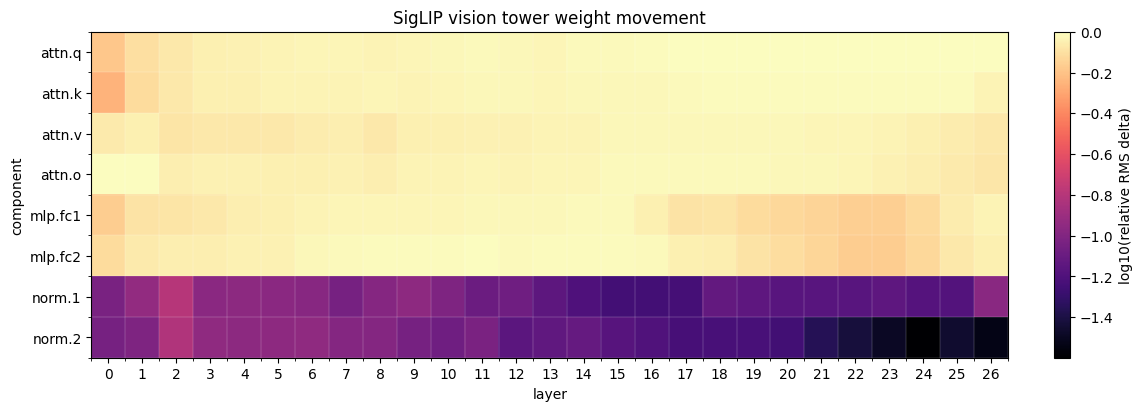

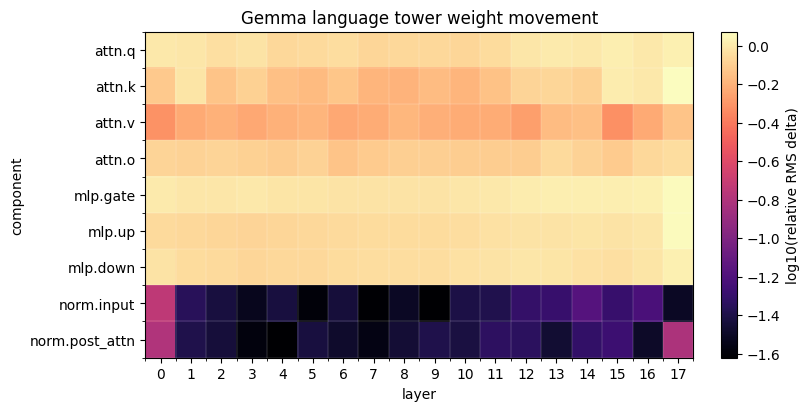

In [7]:
COMPONENT_ORDER = [
    "attn.q", "attn.k", "attn.v", "attn.o",
    "mlp.gate", "mlp.up", "mlp.down", "mlp.fc1", "mlp.fc2",
    "norm.input", "norm.post_attn", "norm.1", "norm.2",
]


def weighted_component_layer_table(df: pd.DataFrame, group: str, value: str = "rel_rms_delta") -> pd.DataFrame:
    sub = df[(df["group"] == group) & df["layer"].notna()].copy()
    if sub.empty:
        return pd.DataFrame()
    table = (
        sub.groupby(["component_short", "layer"])
        .apply(lambda g: np.average(g[value], weights=g["numel"]))
        .rename(value)
        .reset_index()
        .pivot(index="component_short", columns="layer", values=value)
    )
    ordered_rows = [row for row in COMPONENT_ORDER if row in table.index] + [row for row in table.index if row not in COMPONENT_ORDER]
    table = table.loc[ordered_rows]
    table = table.reindex(sorted(table.columns), axis=1)
    return table


def plot_weight_map(table: pd.DataFrame, title: str, *, value_label: str = "relative RMS delta", log_scale: bool = True):
    if table.empty:
        print(f"No data for {title}")
        return
    values = table.to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        print(f"No finite values for {title}")
        return

    plot_values = np.log10(np.maximum(values, 1e-12)) if log_scale else values
    label = f"log10({value_label})" if log_scale else value_label

    fig_w = max(8, 0.42 * table.shape[1])
    fig_h = max(4, 0.42 * table.shape[0])
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)
    im = ax.imshow(plot_values, aspect="auto", cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("layer")
    ax.set_ylabel("component")
    ax.set_xticks(np.arange(table.shape[1]), [str(int(c)) for c in table.columns], rotation=0)
    ax.set_yticks(np.arange(table.shape[0]), table.index)
    ax.set_xticks(np.arange(-.5, table.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, table.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.35, alpha=0.4)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label)
    plt.show()


vision_map = weighted_component_layer_table(metrics_df, "vision")
language_map = weighted_component_layer_table(metrics_df, "language")
plot_weight_map(vision_map, "SigLIP vision tower weight movement")
plot_weight_map(language_map, "Gemma language tower weight movement")

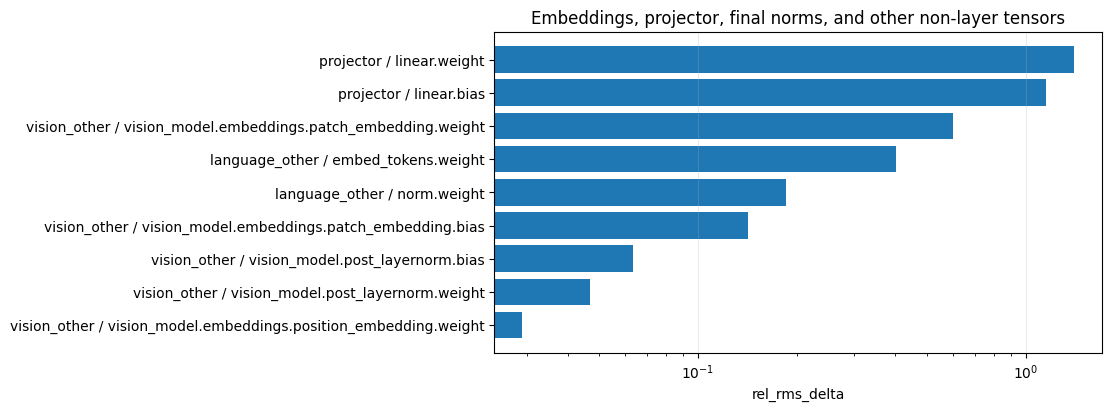

In [8]:
def plot_group_bars(df: pd.DataFrame, groups=("projector", "vision_other", "language_other"), value="rel_rms_delta"):
    sub = df[df["group"].isin(groups)].copy()
    if sub.empty:
        print("No non-layer tensors to plot")
        return
    sub["label"] = sub["group"] + " / " + sub["component_short"] + "." + sub["param"]
    sub = sub.sort_values(value, ascending=True).tail(40)
    fig, ax = plt.subplots(figsize=(11, max(4, 0.28 * len(sub))), constrained_layout=True)
    ax.barh(sub["label"], sub[value], color="tab:blue")
    ax.set_xscale("log")
    ax.set_xlabel(value)
    ax.set_title("Embeddings, projector, final norms, and other non-layer tensors")
    ax.grid(axis="x", alpha=0.25)
    plt.show()


plot_group_bars(metrics_df)

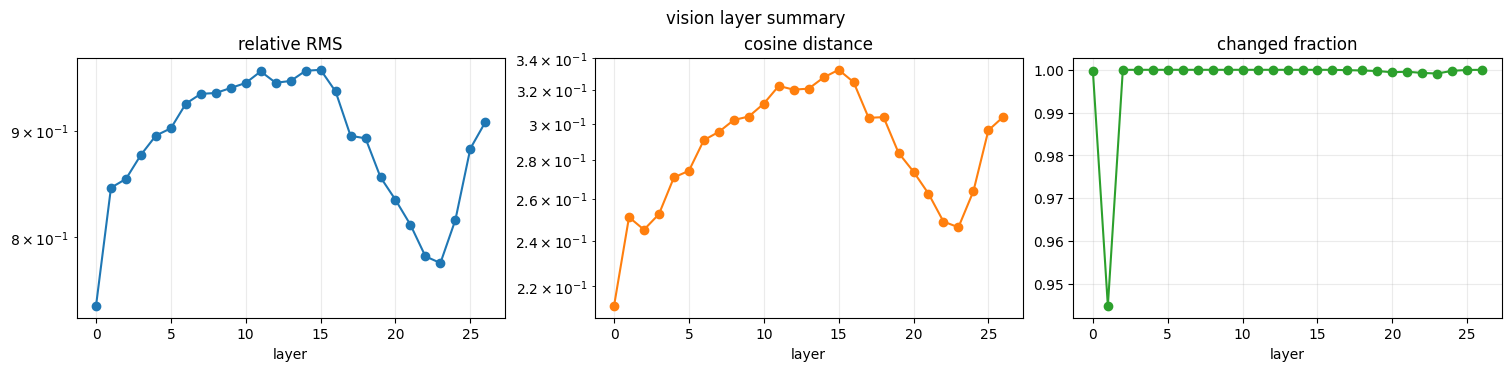

,layer,weighted_rel_rms_delta,weighted_cosine_distance,changed_fraction
0,0.0,0.741471,0.211918,0.999751
1,1.0,0.845145,0.251017,0.944800
2,2.0,0.853421,0.245100,0.999996
3,3.0,0.876475,0.252498,0.999997
4,4.0,0.895398,0.270832,0.999997
5,5.0,0.902630,0.274245,0.999997
6,6.0,0.927599,0.290801,0.999998
7,7.0,0.937714,0.295415,0.999997
8,8.0,0.938601,0.302170,0.999997
9,9.0,0.943855,0.304198,0.999997


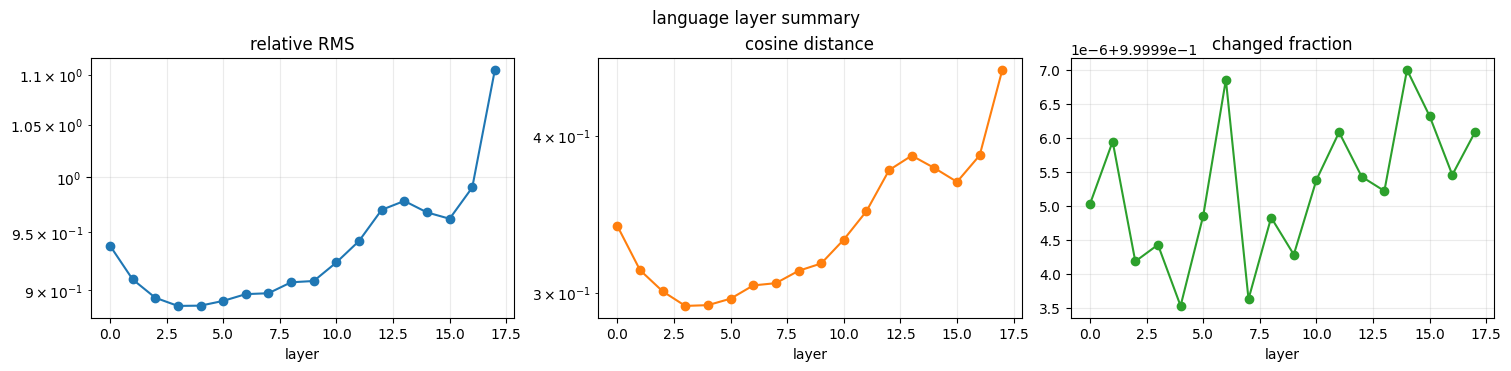

,layer,weighted_rel_rms_delta,weighted_cosine_distance,changed_fraction
0,0.0,0.938134,0.338972,0.999995
1,1.0,0.909085,0.312650,0.999996
2,2.0,0.893688,0.300720,0.999994
3,3.0,0.886884,0.292807,0.999994
4,4.0,0.887104,0.293223,0.999994
5,5.0,0.891028,0.296728,0.999995
6,6.0,0.896676,0.304022,0.999997
7,7.0,0.897418,0.305285,0.999994
8,8.0,0.906617,0.312262,0.999995
9,9.0,0.907707,0.316505,0.999994


In [9]:
def plot_layer_overview(df: pd.DataFrame, group: str, value: str = "rel_rms_delta"):
    sub = df[(df["group"] == group) & df["layer"].notna()].copy()
    if sub.empty:
        return
    layer_summary = (
        sub.groupby("layer")
        .apply(lambda g: pd.Series({
            "weighted_rel_rms_delta": np.average(g["rel_rms_delta"], weights=g["numel"]),
            "weighted_cosine_distance": np.average(g["cosine_distance"], weights=g["numel"]),
            "changed_fraction": np.average(g["changed_fraction"], weights=g["numel"]),
        }))
        .reset_index()
        .sort_values("layer")
    )
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)
    axes[0].plot(layer_summary["layer"], layer_summary["weighted_rel_rms_delta"], marker="o")
    axes[0].set_title("relative RMS")
    axes[0].set_yscale("log")
    axes[1].plot(layer_summary["layer"], layer_summary["weighted_cosine_distance"], marker="o", color="tab:orange")
    axes[1].set_title("cosine distance")
    axes[1].set_yscale("log")
    axes[2].plot(layer_summary["layer"], layer_summary["changed_fraction"], marker="o", color="tab:green")
    axes[2].set_title("changed fraction")
    for ax in axes:
        ax.set_xlabel("layer")
        ax.grid(alpha=0.25)
    fig.suptitle(f"{group} layer summary")
    plt.show()
    display(layer_summary)


plot_layer_overview(metrics_df, "vision")
plot_layer_overview(metrics_df, "language")

## Tensor Drilldown

Select a tensor to inspect its distribution and a block-averaged 2D map. For large matrices, the heatmap downsamples by averaging absolute or signed differences inside fixed-size blocks.

In [10]:
def get_weight_pair(name: str) -> tuple[torch.Tensor, torch.Tensor]:
    return pi05_vlm.state_dict()[name].detach().float().cpu(), base_vlm.state_dict()[name].detach().float().cpu()


def block_reduce_2d(x: np.ndarray, max_rows: int = 96, max_cols: int = 96) -> np.ndarray:
    if x.ndim == 1:
        x = x[None, :]
    elif x.ndim > 2:
        x = x.reshape(x.shape[0], -1)
    row_block = max(1, math.ceil(x.shape[0] / max_rows))
    col_block = max(1, math.ceil(x.shape[1] / max_cols))
    rows = (x.shape[0] // row_block) * row_block
    cols = (x.shape[1] // col_block) * col_block
    if rows == 0 or cols == 0:
        return x
    reduced = x[:rows, :cols].reshape(rows // row_block, row_block, cols // col_block, col_block).mean(axis=(1, 3))
    return reduced


def plot_tensor_drilldown(name: str):
    a, b = get_weight_pair(name)
    if a.shape != b.shape:
        min_shape = tuple(min(x, y) for x, y in zip(a.shape, b.shape, strict=False))
        slices = tuple(slice(0, s) for s in min_shape)
        a, b = a[slices], b[slices]
    diff = a - b
    row = metrics_df.loc[metrics_df["name"] == name].iloc[0]
    print(name)
    display(row[summary_cols].to_frame().T)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), constrained_layout=True)

    axes[0].hist(diff.reshape(-1).numpy(), bins=100, color="tab:blue", alpha=0.85)
    axes[0].set_title("signed differences")
    axes[0].set_xlabel("pi05 - base")
    axes[0].set_ylabel("count")

    abs_map = block_reduce_2d(diff.abs().numpy())
    signed_map = block_reduce_2d(diff.numpy())
    im1 = axes[1].imshow(abs_map, aspect="auto", cmap="magma")
    axes[1].set_title("block mean absolute difference")
    fig.colorbar(im1, ax=axes[1], fraction=0.046)

    vmax = np.percentile(np.abs(signed_map), 99) if signed_map.size else 1.0
    vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1.0
    im2 = axes[2].imshow(signed_map, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[2].set_title("block mean signed difference")
    fig.colorbar(im2, ax=axes[2], fraction=0.046)
    plt.show()


try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

top_names = metrics_df.sort_values("rel_rms_delta", ascending=False)["name"].tolist()
if widgets is None:
    print("ipywidgets is not installed; plotting the most changed tensor instead.")
    plot_tensor_drilldown(top_names[0])
else:
    selector = widgets.Dropdown(
        options=[(f"{i:03d} | {name}", name) for i, name in enumerate(top_names)],
        value=top_names[0],
        layout=widgets.Layout(width="95%"),
        description="tensor",
    )
    output = widgets.interactive_output(plot_tensor_drilldown, {"name": selector})
    display(selector)
    display(output)

Dropdown(description='tensor', layout=Layout(width='95%'), options=(('000 | model.multi_modal_projector.linear…

Output(outputs=({'name': 'stdout', 'text': 'model.multi_modal_projector.linear.weight\n', 'output_type': 'stre…

## Optional Save

In [ ]:
if SAVE_METRICS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    metrics_df.to_parquet(OUTPUT_DIR / "weight_metrics.parquet")
    metrics_df.to_csv(OUTPUT_DIR / "weight_metrics.csv", index=False)
    print(f"Saved metrics under {OUTPUT_DIR}")
else:
    print("SAVE_METRICS=False; not writing metrics")